# Score de risque CG10 — Prédiction d'un éclair nuage-sol dans les 15 prochaines minutes

## Contexte

Dans le cadre de la sécurité aéroportuaire, la foudre de type **nuage-sol (CG)** représente un danger direct pour les opérations au sol. L'objectif de ce notebook est de construire un **score de risque** permettant d'anticiper la survenue d'un tel éclair dans les **15 prochaines minutes** à proximité d'un aéroport (≤ 3 km).

Ce score, fondé sur l'historique récent de l'activité orageuse, doit être :
- **Discriminant** : distinguer les situations à risque des situations calmes
- **Stable** : performant sur des périodes non vues (OOT 2022)
- **Lisible** : interprétable par les opérationnels via des Classes Homogènes de Risque (CHR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

Les données météo pré-traitées sont chargées depuis le fichier pickle produit par la phase de feature engineering. Ce fichier contient le DataFrame enrichi (`df`), la liste des variables candidates (`VAR`), les dummies et les identifiants.

In [2]:
import joblib
path = '..\\data\\meteo_data_clipped.pkl'
meteo_data = joblib.load(path)

In [3]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [4]:
df = meteo_data['df']
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

In [5]:

# 1️⃣ identifier les éclairs cloud-ground dans 3 km
df["cg_3km"] = (
    #(~df["icloud"]) &
    (df["dist"] <= 3)
)

# 2️⃣ créer une colonne avec date seulement pour ces événements
df["cg3_date"] = df["date"].where(df["cg_3km"])

# 3️⃣ prochain événement dans chaque aéroport
df["next_cg3_date"] = (
    df.groupby("airport")["cg3_date"]
    .bfill()
)

# 4️⃣ temps jusqu'au prochain éclair
df["time_to_next_cg3"] = (
    df["next_cg3_date"] - df["date"]
).dt.total_seconds()

df["time_to_next_cg3"]  = df["time_to_next_cg3"].clip(0,3600)
# 5️⃣ supprimer les lignes sans événement futur
df = df[df["time_to_next_cg3"].notna()]



## 2. Exploration de la variable cible `time_to_next_cg20`

Avant de définir la cible binaire, on analyse la distribution du **temps jusqu'au prochain CG ≤ 20 km**. La distribution est très asymétrique (médiane ~47 s, mais 90e percentile à 35 min), ce qui justifie le choix d'un seuil court de **10 minutes** pour capturer les situations à risque immédiat.

In [6]:
df['time_to_next_cg3'].describe()

count    506051.000000
mean       1908.904691
std        1581.233617
min           0.000000
25%         235.000000
50%        1582.000000
75%        3600.000000
max        3600.000000
Name: time_to_next_cg3, dtype: float64

## 3. Définition de la cible binaire

**Formulation du problème de scoring** : pour chaque éclair observé, on veut prédire si un éclair CG surviendra dans les **10 prochaines minutes** à moins de 20 km de l'aéroport.

$$\text{next\_10min\_cg20} = \mathbb{1}[\text{time\_to\_next\_cg20} > 10 \text{ min}]$$

- `True` = **risque faible** (pas de CG dans les 10 prochaines minutes)
- `False` = **risque actif** (CG imminent)

> Note : la variable est définie comme "absence de CG" pour aligner la convention avec un score croissant.

In [7]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_15min_all3'] = df['time_to_next_cg3'] <= (15 * 60) # LE prochain arrive dans moins de 15 minutes
df['next_15min_all3'].value_counts()

next_15min_all3
False    289367
True     216684
Name: count, dtype: int64

In [8]:
df.groupby("season")["next_15min_all3"].mean()

season
Automne      0.440909
Hiver        0.132989
Printemps    0.239440
Été          0.469201
Name: next_15min_all3, dtype: float64

## 2. Construction de la cible binaire

On discrétise `time_to_next_cg20` avec le seuil à **15 minutes (900 secondes)**.

Le déséquilibre (~90% / 10%) est caractéristique des problèmes d'alerte :
la majorité du temps, un CG arrive dans les 15 minutes car les éclairs se produisent en rafales.
La classe rare (pas de CG imminent) est précisément ce que le score doit détecter.

Prévalence (pas de CG dans 15 min) : 42.82%
next_15min_all3
False    289367
True     216684
Name: count, dtype: int64


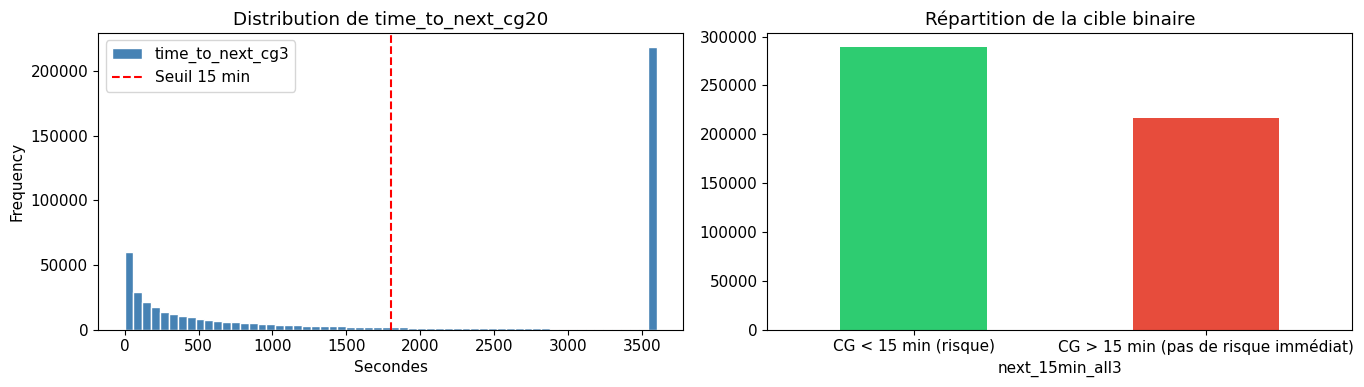

In [9]:
target_col = 'next_15min_all3'
prevalence = df[target_col].mean()
print(f'Prévalence (pas de CG dans 15 min) : {prevalence:.2%}')
print(df[target_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['time_to_next_cg3'].plot.hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(1800, color='red', linestyle='--', label='Seuil 15 min')
axes[0].set_title('Distribution de time_to_next_cg20')
axes[0].set_xlabel('Secondes')
axes[0].legend()

df[target_col].value_counts().plot.bar(ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Répartition de la cible binaire')
axes[1].set_xticklabels(['CG < 15 min (risque)', 'CG > 15 min (pas de risque immédiat)'], rotation=0)
plt.tight_layout()
plt.show()

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




### Découpage temporel

- **Train** : 2015–2021, 70 % aléatoire stratifié — sert à l'entraînement et à la calibration des hyperparamètres
- **Test** : 2015–2021, 15 % restant — évaluation interne
- **OOT** : 2022 — données hors-temps, jamais vues lors du développement, servent de validation finale

In [10]:
from sklearn.model_selection import train_test_split

data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2021)
stratify_col = (data[target_col].astype(str)+ "_" + data['airport'] + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.2, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2022].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((343496, 113), (85874, 113), (76681, 113))

### Préparation des matrices X / y

On sépare les features (`VAR` + variables catégorielles encodées one-hot : `airport`, `season`) de la cible. L'encodage est aligné entre les trois jeux pour éviter tout décalage de colonnes.

In [11]:
X_train = train_data[VAR+["airport",'season']].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[VAR+["airport",'season']].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[VAR+["airport",'season']].copy()
y_oot = oot_data[target_col].copy()*1

# IMPUTATION

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit sur train uniquement
X_train[VAR] = imputer.fit_transform(X_train[VAR])

# Transform sur test et OOT avec les médianes du train
X_test[VAR] = imputer.transform(X_test[VAR])
X_oot[VAR]  = imputer.transform(X_oot[VAR])

print("Médianes utilisées :")
print(dict(zip(VAR+["airport",'season'], imputer.statistics_)))


Médianes utilisées :
{'min_dist_5min': np.float64(6.309350771198902), 'time_since_last_CG20_2': np.float64(3.828641396489095), 'log_count_30min': np.float64(5.717027701406222), 'amplitude_change': np.float64(0.04417565074810148), 'activity_decay': np.float64(1.0528790705956428), 'time_since_last_intra_cloud2': np.float64(1.6094379124341003), 'log_cg_count_10min': np.float64(3.1780538303479458), 'min_dist_1min': np.float64(10.583768168351147), 'cg_20km': np.float64(0.0), 'log_std_amplitude_10min': np.float64(2.3390500940454944), 'is_cloud_ground': np.float64(0.0), 'log_cg_count_20min': np.float64(3.7612001156935624), 'burst_indicator': np.float64(1.0), 'hour': np.float64(13.0), 'storm_direction_change': np.float64(3.026620380948666), 'time_since_last_cloud_ground2': np.float64(2.833213344056216), 'std_lat_10min': np.float64(0.07467822069901484), 'mean_dist_1min': np.float64(20.569320239566146), 'dist': np.float64(21.342852244923243), 'log_count_5min': np.float64(4.174387269895637), 'ale

## 4. Sélection des variables candidates

Les variables sont pré-sélectionnées selon leur importance SHAP issue d'un premier modèle benchmark, en favorisant :
- l'**activité récente** (comptages log sur 5, 10, 20 min)
- la **distance minimale** (indicateur de proximité)
- la **dispersion angulaire** (étalement de l'orage)
- les **délais** depuis le dernier CG (inertie orageuse)

In [13]:
top_var = ['min_dist_10min', 'min_dist_1min', 'log_cg_count_10min', 'log_cg_count_5min', 
           'log_count_5min', 'log_count_10min', 'log_cg_count_20min', 'std_azimuth_1min', 
           'mean_dist_5min', 'log_count_20min', 'std_azimuth_10min', 'rate_trend', 'mean_dist_1min', 
           'log_count_1min', 'storm_spread', 'mean_dist_10min', 'log_ic_count_5min',
             'log_ic_count_10min', 'log_ic_count_20min', 'std_lon_10min', 'std_lat_10min', 
             'time_since_last_lightning2', 'burst_indicator', 'time_since_last_cloud_ground2', 'activity_decay', 
             'max_amplitude_10min', 'dist', 'max_amplitude_1min', 'mean_azimuth_1min', 'mean_azimuth_10min',
               'storm_direction_change', 'distance_trend', 'season', 'cg_20km', 'alert_duration', 'azimuth', 'azimuth_change']
len(top_var)

37

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_vars = top_var
#  = ['log_cg_count_5min', 'log_count_5min', 'log_cg_count_10min',
#        'mean_dist_5min', 'cg_20km', 'min_dist_1min', 'log_count_1min',
#        'min_dist_5min', 'log_ic_count_5min', 'mean_dist_10min',
#        'mean_dist_1min', 'hour', 'log_cg_count_20min', 'storm_spread',
#        'min_dist_10min', 'mean_azimuth_10min', 'log_count_15min',
#        'mean_azimuth_1min', 'time_since_last_lightning2',
#        'storm_center_distance']#VAR+["airport",'season'] 

X_train = train_data[xgb_vars].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[xgb_vars].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[xgb_vars].copy()
y_oot = oot_data[target_col].copy()*1
combined = pd.concat([X_train, X_test,X_oot], keys=['train', 'test','oot'])
combined_enc = pd.get_dummies(combined)

#Séparer avec les mêmes colonnes
X_train_enc = combined_enc.xs('train')#
X_test_enc = combined_enc.xs('test')
X_oot_enc = combined_enc.xs('oot')



## 5. Modèle XGBoost

On entraîne un **XGBClassifier** (`binary:logistic`) avec les hyperparamètres optimisés par **Optuna** (50 trials, 3-fold CV stratifié sur le train). L'algorithme histogram (`tree_method=hist`) accélère l'entraînement sur ce volume de données (~350 k lignes).

In [15]:
# import optuna
# from xgboost import XGBClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# def objective(trial):
#     params = {
#         "objective":        "binary:logistic",
#         "eval_metric":      "auc",
#         "tree_method":      "hist",
#         "random_state":     42,
#         "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
#         "max_depth":        trial.suggest_int("max_depth", 3, 8),
#         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "gamma":            trial.suggest_float("gamma", 0, 15),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
#         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
#         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
#     }

#     model = XGBClassifier(**params,eval_set=[(X_test_enc, y_test)])
#     scores = cross_val_score(model, X_train_enc, y_train,
#                              cv=cv, scoring="roc_auc", n_jobs=-1)
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=15, show_progress_bar=True)

# print(f"Meilleur AUC CV : {study.best_value:.4f}")
# print("Meilleurs paramètres :")
# study.best_params


### Hyperparamètres optimisés (Optuna — 3-fold CV)

Les paramètres ci-dessous ont été sélectionnés pour **maximiser le ROC AUC** en validation croisée stratifiée. La régularisation L1/L2 (`reg_alpha`, `reg_lambda`) et `min_child_weight` élevé limitent le surapprentissage.

In [16]:
params = {'n_estimators': 340,
 'max_depth': 7,
 'learning_rate': 0.18630628262434443,
 'subsample': 0.9870394487089063,
 'colsample_bytree': 0.6786921576593067,
 'gamma': 1.2540924325081915,
 'min_child_weight': 15,
 'reg_alpha': 0.008397656439471051,
 'reg_lambda': 0.06342656422775246}

model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    **params
)
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_test_enc, y_test)], verbose=False)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6786921576593067
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## 6. Évaluation des performances

Métriques calculées sur les trois jeux :

| Métrique | Description |
|---|---|
| **ROC AUC** | Discrimination globale (insensible au seuil) |
| **Gini** | 2 × AUC − 1, normalisé entre 0 et 1 |
| **PR AUC** | AUC de la courbe Précision-Rappel, adaptée aux classes déséquilibrées |
| **Ratio RP** | PR AUC / prévalence — un modèle aléatoire vaut 1.0 |

In [17]:
from sklearn.metrics import average_precision_score
y_pred = model_xgb.predict(X_oot_enc)
print(classification_report(y_oot, y_pred))

proba_train = model_xgb.predict_proba(X_train_enc)[:, 1]
proba_test  = model_xgb.predict_proba(X_test_enc)[:, 1]
proba_oot  = model_xgb.predict_proba(X_oot_enc)[:, 1]

prevalence = y_test.mean()

auc_train   = roc_auc_score(y_train, proba_train)
gini_train  = 2 * auc_train - 1

auc_test    = roc_auc_score(y_test, proba_test)
auc_pr_test = average_precision_score(y_test, proba_test)
rp          = auc_pr_test / prevalence
gini_test  = 2 * auc_test - 1

auc_oot    = roc_auc_score(y_oot, proba_oot)
auc_pr_oot = average_precision_score(y_oot, proba_oot)
rp_o          = auc_pr_oot / y_oot.mean()
gini_oot  = 2 * auc_oot - 1
print(f"ROC AUC TRAIN: {auc_train:.4f}  |  Gini TRAIN: {gini_train:.4f}")
print(f"ROC AUC TEST:  {auc_test:.4f} |  Gini Test: {gini_test:.4f}")
print(f"PR AUC TEST:   {auc_pr_test:.4f}  |  Ratio RP: {rp:.4f}")
print(f"ROC AUC OOT:  {auc_oot:.4f} |  Gini OOT: {gini_oot:.4f}")
print(f"PR AUC OOT:   {auc_pr_oot:.4f}  |  Ratio RP OOT: {rp_o:.4f}")


              precision    recall  f1-score   support

           0       0.82      0.85      0.83     48053
           1       0.73      0.69      0.71     28628

    accuracy                           0.79     76681
   macro avg       0.77      0.77      0.77     76681
weighted avg       0.78      0.79      0.79     76681

ROC AUC TRAIN: 0.9993  |  Gini TRAIN: 0.9985
ROC AUC TEST:  0.9977 |  Gini Test: 0.9954
PR AUC TEST:   0.9978  |  Ratio RP: 2.2782
ROC AUC OOT:  0.8487 |  Gini OOT: 0.6973
PR AUC OOT:   0.7993  |  Ratio RP OOT: 2.1410


### Calcul des scores (probabilités × 1000)

On transforme les probabilités brutes en **points** entre 0 et 1000. Un point élevé indique un risque élevé de CG dans les 10 prochaines minutes. Cette mise à l'échelle facilite la lecture opérationnelle et la construction des CHR.

In [18]:
test_data['probas'] = proba_test
train_data['probas'] = proba_train
oot_data['probas'] = proba_oot
test_data['points'] = proba_test*1000
train_data['points'] = proba_train*1000
oot_data['points'] = proba_oot*1000

In [19]:
# import shap

# explainer = shap.TreeExplainer(model_xgb)
# shap_values = explainer.shap_values(X_train_enc)

# shp = shap.summary_plot(shap_values, X_train_enc, plot_type="bar")


In [20]:
# # Importance = moyenne des |valeurs SHAP|
# importance = pd.Series(
#     np.abs(shap_values).mean(axis=0),
#     index=X_train_enc.columns
# ).sort_values(ascending=False)

# print(importance.to_string())

In [21]:
# feat_names = X_train_enc.columns.tolist()
# shap.plots.violin(
#     shap_values,
#     features=X_train_enc,
#     feature_names=feat_names,
#     plot_type="layered_violin",
#     max_display=20  # Limite à 20 variables les plus importantes
# )

# Analyse des performances

## AUC maské

In [22]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


### par aeroport

In [23]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [24]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Pise,27036,0.390442,0.997444,0.994887,0.997110,2.553796
Nantes,5831,0.420854,0.997830,0.995660,0.997579,2.370368
Ajaccio,11243,0.423641,0.994854,0.989709,0.994832,2.348288
Biarritz,19170,0.460668,0.997772,0.995544,0.998056,2.166543
Bastia,22594,0.487120,0.998978,0.997956,0.999098,2.051028


In [25]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,12812,0.300578,0.858105,0.716209,0.806645,2.683648
Pise,20869,0.360487,0.875874,0.751748,0.814457,2.259326
Nantes,7423,0.279402,0.738657,0.477315,0.522257,1.869198
Biarritz,19307,0.354794,0.776406,0.552812,0.654669,1.845210
Ajaccio,16270,0.511985,0.905375,0.810749,0.927918,1.812392


### par saison

In [26]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Hiver,2102,0.120362,0.964346,0.928691,0.900117,7.478442
Printemps,8452,0.187293,0.990842,0.981685,0.981029,5.237937
Automne,27698,0.450610,0.997596,0.995191,0.997716,2.214144
Été,47622,0.489123,0.998630,0.997261,0.998809,2.042043


In [27]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Hiver,924,0.271645,0.827957,0.655914,0.658992,2.425933
Été,50431,0.374968,0.884390,0.768779,0.864106,2.304480
Automne,12596,0.334074,0.860239,0.720478,0.751223,2.248669
Printemps,12730,0.413119,0.735734,0.471468,0.650721,1.575142


## 8. Analyse restreinte aux éclairs CG ≤ 20 km

On analyse les performances et la stabilité des CHR **uniquement sur les éclairs nuage-sol proches** (CG ≤ 20 km), qui constituent la population la plus exposée au risque opérationnel direct.

In [28]:
auc_mask(test_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
False,76196,0.430863,0.997995,0.995991,0.998013,2.316314
True,9678,0.493904,0.994604,0.989208,0.995612,2.015803


In [29]:
auc_mask(oot_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
False,68179,0.356415,0.854464,0.708927,0.798649,2.240785
True,8502,0.509057,0.789003,0.578005,0.809660,1.590511


## quelques plots

### Distribution des scores par classe

Les graphiques empilés montrent la répartition des **bons** (pas de CG < 10 min) et **mauvais** (CG < 10 min) selon les intervalles de score. Un bon score présente une séparation nette des deux populations : les mauvais se concentrent sur les scores élevés.

In [30]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#e74c3c','#2ecc71'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['CG20 imminent', 'Last CG20'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of last CG by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



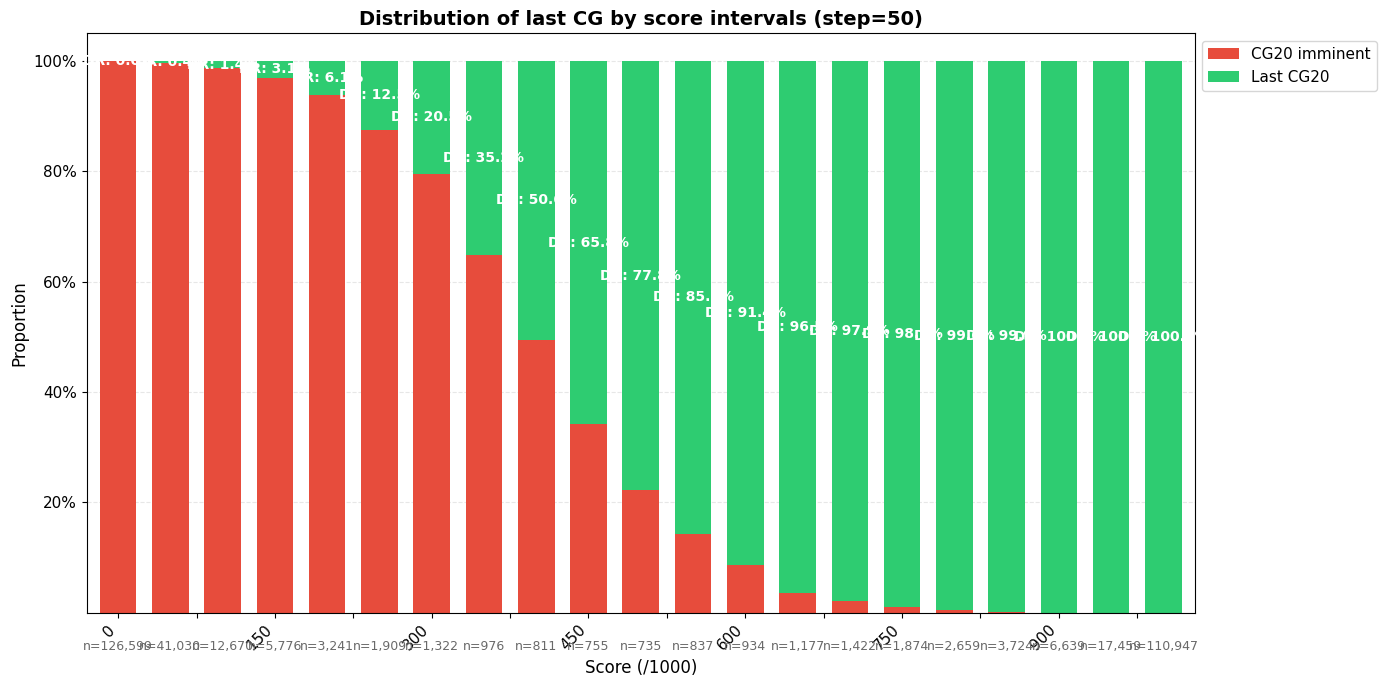


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0 126599       126543       56        0.04%
    50  41030        40884      146        0.36%
   100  12670        12496      174        1.37%
   150   5776         5598      178        3.08%
   200   3241         3042      199        6.14%
   250   1909         1670      239       12.52%
   300   1322         1051      271       20.50%
   350    976          632      344       35.25%
   400    811          401      410       50.55%
   450    755          258      497       65.83%
   500    735          163      572       77.82%
   550    837          120      717       85.66%
   600    934           80      854       91.43%
   650   1177           41     1136       96.52%
   700   1422           30     1392       97.89%
   750   1874           20     1854       98.93%
   800   2659           11     2648       99.59%
   850   3724            5     3719       99.87%
   900   6639            1     6638       

In [31]:
score_graph_empile(train_data, score_col='points', label_col=target_col, pas=50)
#probas_graph_empile(train_data, score_col='points', label_col='default_t_plus_1', pas=0.05)

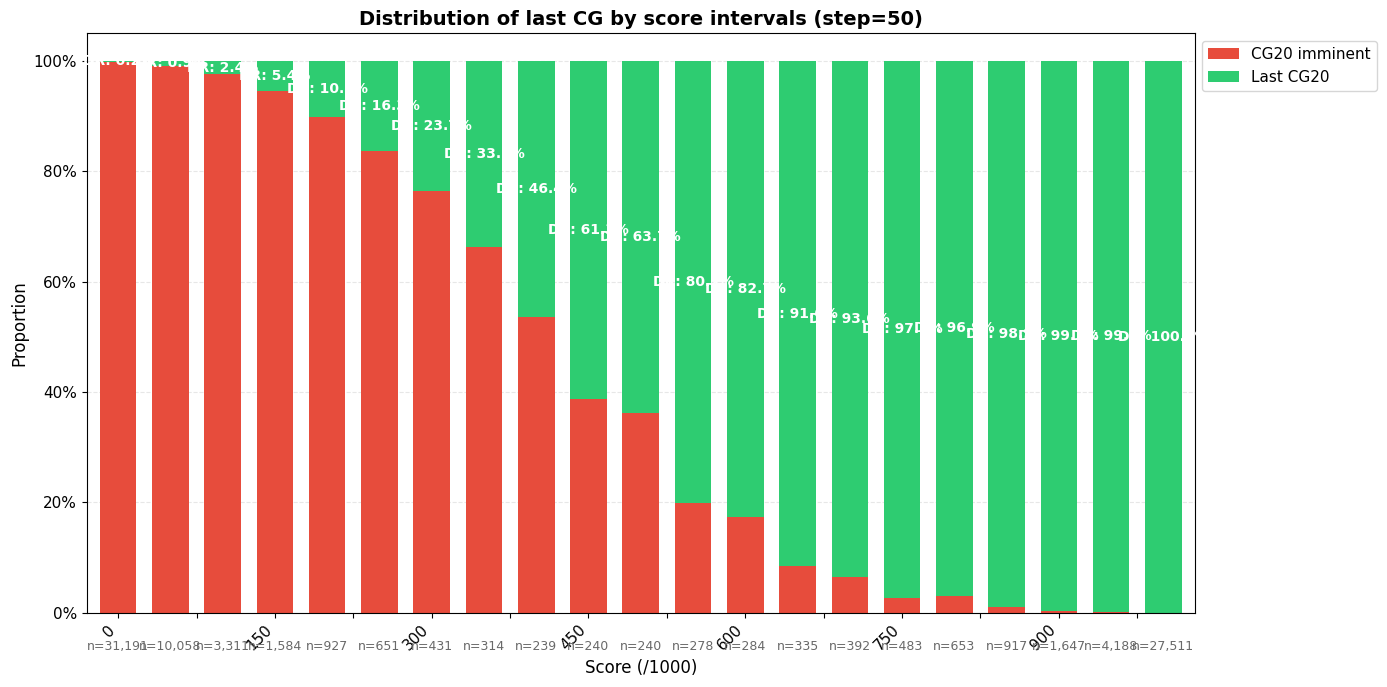


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  31191        31130       61        0.20%
    50  10058         9970       88        0.87%
   100   3311         3231       80        2.42%
   150   1584         1499       85        5.37%
   200    927          832       95       10.25%
   250    651          545      106       16.28%
   300    431          329      102       23.67%
   350    314          208      106       33.76%
   400    239          128      111       46.44%
   450    240           93      147       61.25%
   500    240           87      153       63.75%
   550    278           55      223       80.22%
   600    284           49      235       82.75%
   650    335           28      307       91.64%
   700    392           25      367       93.62%
   750    483           13      470       97.31%
   800    653           20      633       96.94%
   850    917           10      907       98.91%
   900   1647            5     1642       

In [32]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


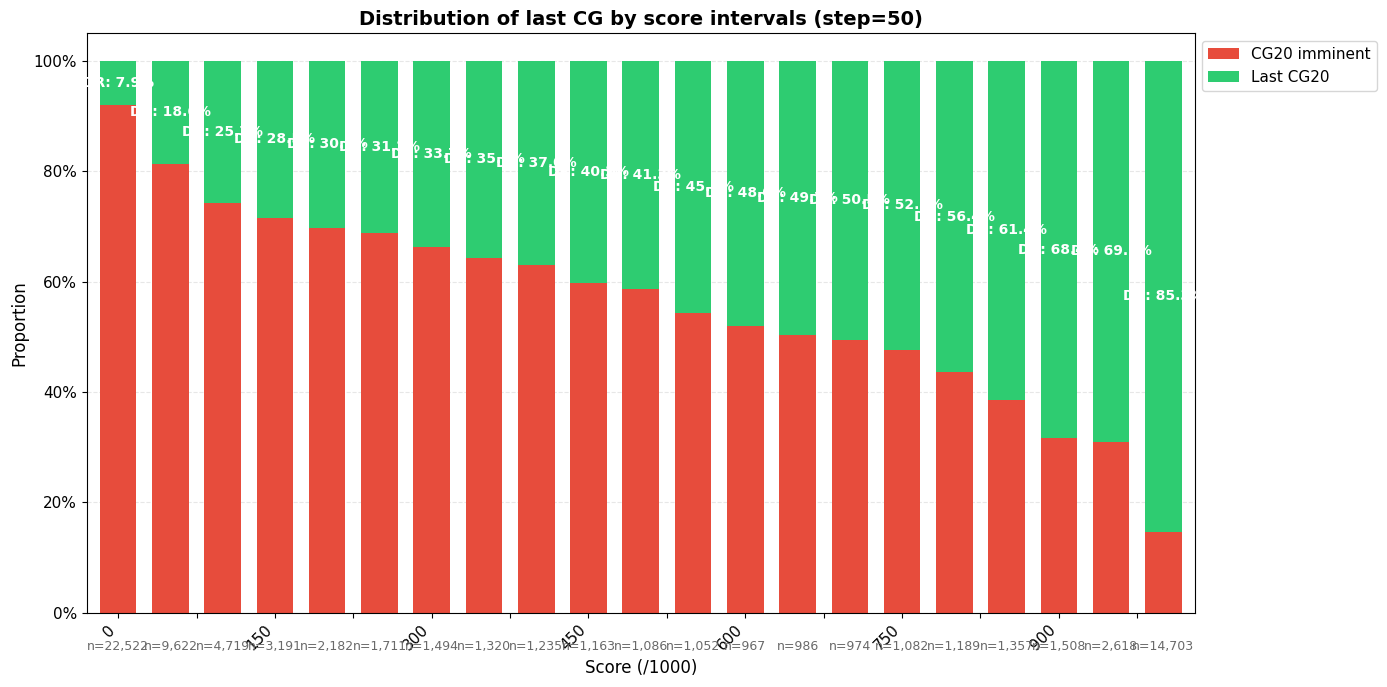


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  22522        20734     1788        7.94%
    50   9622         7828     1794       18.64%
   100   4719         3505     1214       25.73%
   150   3191         2282      909       28.49%
   200   2182         1522      660       30.25%
   250   1711         1177      534       31.21%
   300   1494          991      503       33.67%
   350   1320          849      471       35.68%
   400   1235          778      457       37.00%
   450   1163          695      468       40.24%
   500   1086          638      448       41.25%
   550   1052          572      480       45.63%
   600    967          503      464       47.98%
   650    986          496      490       49.70%
   700    974          482      492       50.51%
   750   1082          516      566       52.31%
   800   1189          518      671       56.43%
   850   1357          524      833       61.39%
   900   1508          477     1031       

In [33]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


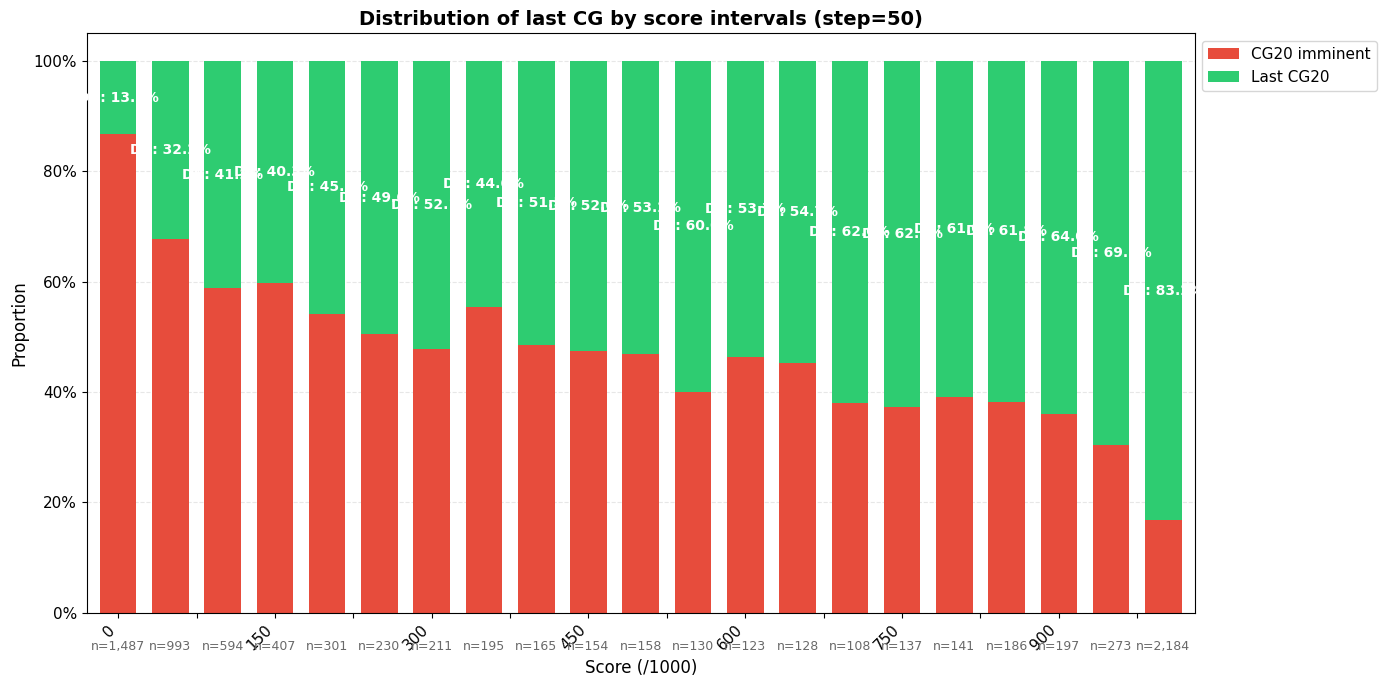


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0   1487         1289      198       13.32%
    50    993          673      320       32.23%
   100    594          349      245       41.25%
   150    407          243      164       40.29%
   200    301          163      138       45.85%
   250    230          116      114       49.57%
   300    211          101      110       52.13%
   350    195          108       87       44.62%
   400    165           80       85       51.52%
   450    154           73       81       52.60%
   500    158           74       84       53.16%
   550    130           52       78       60.00%
   600    123           57       66       53.66%
   650    128           58       70       54.69%
   700    108           41       67       62.04%
   750    137           51       86       62.77%
   800    141           55       86       60.99%
   850    186           71      115       61.83%
   900    197           71      126       

In [34]:
score_graph_empile(oot_data.loc[oot_data['cg_20km']], score_col='points', label_col=target_col, pas=50)


## 9. Sauvegarde des artefacts du modèle

On sauvegarde dans un unique fichier pickle tous les éléments nécessaires à la mise en production du score :

| Objet | Description |
|---|---|
| `model` | XGBClassifier fitté |
| `vars_to_use` | Liste des features d'entrée |
| `best_params` | Hyperparamètres Optuna |
| `imputer` | SimpleImputer fitté sur train (médianes) |
| `breaks` | Intervalles de discrétisation des scores → CHR |
| `bin_stats` | Taux de risque CG par CHR (calibration test+OOT) |
| `performance` | Résumé AUC / Gini / RP sur train, test et OOT |

In [36]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

artefacts = {
    'model'       : model_xgb,
    'vars_to_use' : xgb_vars,
    'best_params' : params,
    'imputer'     : imputer,
    'performance' : {
        'train': {'auc': auc_train, 'gini': gini_train},
        'test' : {'auc': auc_test,  'auc_pr': auc_pr_test, 'rp': rp},
        'oot'  : {'auc': auc_oot,   'auc_pr': auc_pr_oot,  'rp': rp_o},
    },
}

save_path = '../models/xgb_all15_3km_artefacts.pkl'
joblib.dump(artefacts, save_path)
print(f'Artefacts sauvegardes dans {save_path}')
print(f'  Variables      : {len(xgb_vars)}')
print(f'  Hyperparametres: {list(params.keys())}')
print(f'  ROC AUC train  : {auc_train:.4f}  |  test : {auc_test:.4f}  |  OOT : {auc_oot:.4f}')


Artefacts sauvegardes dans ../models/xgb_all15_3km_artefacts.pkl
  Variables      : 37
  Hyperparametres: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_alpha', 'reg_lambda']
  ROC AUC train  : 0.9993  |  test : 0.9977  |  OOT : 0.8487
